# Deep Learning with Keras: Classification and Regression Case Studies

This notebook demonstrates fundamental concepts of deep learning using Keras for various tasks:

1.  **Binary Classification:** Predicting movie review sentiment using the IMDB dataset.
2.  **Multiclass Classification:** Categorizing news wire topics using the Reuters dataset.
3.  **Regression:** Predicting housing prices using the Boston Housing dataset.

## Case Study 1: Binary Classification - IMDB Movie Reviews

This section focuses on classifying movie reviews as positive or negative using the IMDB dataset. We'll preprocess the text data, build a neural network, train it, and evaluate its performance.

In [ ]:
from tensorflow.keras.datasets import imdb

In [ ]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Data Loading and Exploration

The IMDB dataset consists of 50,000 highly polarized movie reviews (25,000 for training, 25,000 for testing). Each review is a sequence of word indices. We load only the top 10,000 most frequently occurring words to manage complexity and prevent overfitting.

In [ ]:
#train_data[0]

In [ ]:
train_data.shape

(25000,)

In [ ]:
train_labels.shape

(25000,)

In [ ]:
train_labels[0]

np.int64(1)

In [ ]:
max(max(sequence) for sequence in train_data)

9999

### Decoding Reviews

To understand the raw data, we can decode an integer sequence back into human-readable text. The `word_index` dictionary helps us map integers back to words. Note that indices 0, 1, and 2 are reserved for 'padding', 'start of sequence', and 'unknown' words, respectively, so we subtract 3 from each index.

In [ ]:
#Decoding reviews back to text
word_index = imdb.get_word_index() #word index is a dictionary mapping word to an integer
rev_word_index = dict(
    [(value,key) for (key,value) in word_index.items()]) #reverses mapping integer indices to words
decoded_review = " ".join(
    [rev_word_index.get(i - 3, "?") for i in train_data[0]]) #i-3 because 0,1,2 are reserved for "padding", "start of sequence" & "unkown"


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [ ]:
len(train_data[2])

141

### Data Vectorization (Multi-Hot Encoding)

Neural networks cannot directly process integer sequences. We need to transform them into a format that the network can handle, typically vectors. Here, we use multi-hot encoding: each review is converted into a vector of 10,000 dimensions (the size of our vocabulary), where specific indices are set to 1 to indicate the presence of a word, and 0 otherwise. This creates a binary representation of the word presence.

In [ ]:
#encoding the integer sequences via multi-hot encoding
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for j in sequence:
      results[i,j] = 1.
  return results
X_train = vectorize_sequences(train_data)
X_test = vectorize_sequences(test_data)

In [ ]:
X_train.shape

(25000, 10000)

In [ ]:
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [ ]:
#vectorizing labels
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

### Vectorizing Labels

The labels (positive or negative sentiment) are also converted to a numerical format (float32) for compatibility with the neural network.

In [ ]:
#model
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu"),       #output=relu(dot(input,W) + b)
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])


### Model Definition

We define a simple feedforward neural network (Sequential model) with:

*   Two hidden `Dense` layers, each with 16 units and a `relu` activation function. `relu` (rectified linear unit) is a common choice for hidden layers.
*   An output `Dense` layer with 1 unit and a `sigmoid` activation function. `sigmoid` outputs a probability (a value between 0 and 1), which is suitable for binary classification tasks.

The model is compiled with:
*   `rmsprop` optimizer: A popular and effective optimizer.
*   `binary_crossentropy` loss: The standard loss function for binary classification problems where the output is a probability.
*   `accuracy` metric: To monitor the proportion of correctly classified reviews during training and evaluation.

In [ ]:
X_train.shape

(25000, 10000)

### Preparing Validation Data

To monitor the model's performance on unseen data during training and prevent overfitting, we split the training data into a training set and a validation set. Here, the first 10,000 samples from `X_train` and `y_train` are used for validation.

In [ ]:
x_val =X_train[:10000]
partial_x_train = X_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [ ]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 20,
                    batch_size=512,
                    validation_data =(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5016 - loss: 0.6937 - val_accuracy: 0.4967 - val_loss: 0.6948
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5605 - loss: 0.6835 - val_accuracy: 0.5038 - val_loss: 0.6960
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6270 - loss: 0.6563 - val_accuracy: 0.4962 - val_loss: 0.7067
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6789 - loss: 0.6184 - val_accuracy: 0.5043 - val_loss: 0.7184
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7187 - loss: 0.5797 - val_accuracy: 0.4986 - val_loss: 0.7412
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7587 - loss: 0.5380 - val_accuracy: 0.5014 - val_loss: 0.7586
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7748 - loss: 0.5026 - val_accuracy: 0.5016 - val_loss: 0.7832
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8047 - loss: 0.4637 - val_accuracy: 0.4991 - v

### Model Training

The model is trained on the `partial_x_train` and `partial_y_train` datasets for 20 epochs with a batch size of 512. During training, the `validation_data` is used to evaluate the model's performance on the validation set at the end of each epoch.

In [ ]:
history_dict = history.history
history_dict.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

### Plotting Training and Validation Loss/Accuracy

These plots help visualize the training process. Typically, you want to see training loss decrease and training accuracy increase. The validation metrics indicate how well the model generalizes to new data. If validation loss starts increasing while training loss continues to decrease, it's a sign of overfitting.

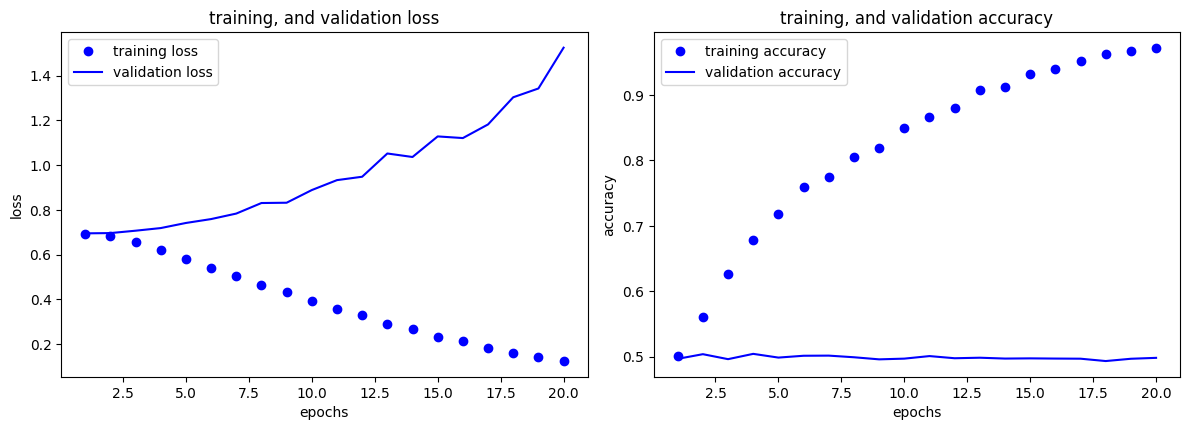

In [ ]:
import matplotlib.pyplot as plt

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]

epochs = range(1, len(loss_values)+1)

plt.figure(figsize=(12,8))

#plotting training and validation loss
plt.subplot(2,2,1)
plt.plot(epochs, loss_values, "bo", label="training loss")
plt.plot(epochs, val_loss_values, "b", label="validation loss")
plt.title("training, and validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
#plt.show()

#plotting training and validation accuracy
plt.subplot(2,2,2)
plt.plot(epochs, accuracy, "bo", label="training accuracy")
plt.plot(epochs, val_accuracy, "b", label = "validation accuracy")
plt.title("training, and validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()



The plots show that after a few epochs, the validation loss starts to increase while the training loss continues to decrease. This is a clear indication of overfitting. The validation accuracy also plateaus or slightly decreases, reinforcing this observation. This suggests that the model is learning the training data too well and losing its ability to generalize to unseen data.

In [ ]:
#retraining the model

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer = "rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=4, batch_size=512)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8166 - loss: 0.4638
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9021 - loss: 0.2737
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9218 - loss: 0.2152
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9333 - loss: 0.1846


### Retraining the Model with Optimal Epochs

Based on the plots, it appears that the model starts overfitting around 4 epochs. To get a better generalizing model, we retrain the model from scratch on the entire training dataset (`X_train`, `y_train`) but for a reduced number of epochs (4 epochs in this case) to prevent overfitting.

In [ ]:
results = model.evaluate(X_test, y  = y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8848 - loss: 0.2884


### Model Evaluation

Finally, the retrained model is evaluated on the completely unseen test dataset (`X_test`, `y_test`) to get an unbiased estimate of its performance.

In [ ]:
model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.22369859],
       [0.99961036],
       [0.7744962 ],
       ...,
       [0.0959577 ],
       [0.07033169],
       [0.5807894 ]], dtype=float32)

### Generating Predictions

The `predict` method returns the probability of each review being positive. Since it's binary classification, values closer to 1 indicate a positive review, and values closer to 0 indicate a negative review.

In [ ]:
%reset -f

### Clear Session

`%reset -f` clears all variables from the current IPython session. This is useful when moving to a new case study to ensure there are no unintended dependencies or memory issues from previous runs.

## Case Study 2: Multiclass Classification - Reuters News Wires

This section tackles multiclass classification using the Reuters dataset, which consists of news wires categorized into 46 different topics. The goal is to predict the topic of a given news wire.

In [ ]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Data Loading and Exploration

Similar to IMDB, the Reuters dataset contains news wires as sequences of word indices. We load the top 10,000 most frequent words. Each news wire is associated with a label indicating its topic.

In [ ]:
train_data.shape

(8982,)

In [ ]:
len(test_data)

2246

In [ ]:
train_data[0]

[1,
 2,
 2,
 8,
 43,
 10,
 447,
 5,
 25,
 207,
 270,
 5,
 3095,
 111,
 16,
 369,
 186,
 90,
 67,
 7,
 89,
 5,
 19,
 102,
 6,
 19,
 124,
 15,
 90,
 67,
 84,
 22,
 482,
 26,
 7,
 48,
 4,
 49,
 8,
 864,
 39,
 209,
 154,
 6,
 151,
 6,
 83,
 11,
 15,
 22,
 155,
 11,
 15,
 7,
 48,
 9,
 4579,
 1005,
 504,
 6,
 258,
 6,
 272,
 11,
 15,
 22,
 134,
 44,
 11,
 15,
 16,
 8,
 197,
 1245,
 90,
 67,
 52,
 29,
 209,
 30,
 32,
 132,
 6,
 109,
 15,
 17,
 12]

In [ ]:
train_labels[1]

np.int64(4)

### Decoding News Wires

We can decode an integer sequence from the Reuters dataset back into readable text using the `word_index` to understand the content of a news wire. As with IMDB, indices 0, 1, and 2 are reserved.

In [ ]:
word_index = reuters.get_word_index()
rev_word_index = dict([(value,key) for (key,value) in word_index.items()])
decoded_newswire = " ".join([rev_word_index.get(i-3, "?") for i in train_data[0]])

In [ ]:
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

### Data Vectorization (Multi-Hot Encoding)

The news wire sequences are multi-hot encoded into vectors of 10,000 dimensions, similar to the IMDB dataset. Each vector indicates the presence of words in the vocabulary.

In [ ]:
#encoding the integer sequences via multi-hot encoding
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for j in sequence:
      results[i,j] = 1.
  return results
X_train = vectorize_sequences(train_data)
X_test = vectorize_sequences(test_data)

### Encoding Labels (One-Hot Encoding)

For multiclass classification with more than two classes, it's standard practice to use one-hot encoding for the labels. `to_categorical` converts integer labels into binary vectors, where only the index corresponding to the class is 1, and all others are 0. Since there are 46 topics, each label becomes a 46-dimensional vector.

In [ ]:
#Encoding the labels
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(8982, 10000)
(8982, 46)


### Model Definition

For multiclass classification with 46 distinct classes, the model architecture is adjusted:

*   Two hidden `Dense` layers with 64 units and `relu` activation.
*   An output `Dense` layer with 46 units (one for each class) and a `softmax` activation function. `softmax` outputs a probability distribution over the 46 classes, meaning the sum of all outputs will be 1.

The model is compiled with:
*   `rmsprop` optimizer.
*   `categorical_crossentropy` loss: The appropriate loss function for multiclass classification when labels are one-hot encoded.
*   `accuracy` metric.

In [ ]:
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [ ]:
y_train[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
#model
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer = "rmsprop",
              loss= "categorical_crossentropy",
              metrics=["accuracy"])

### Preparing Validation Data

Similar to the IMDB case, a validation set is created from the training data to monitor performance and detect overfitting. Here, the first 1,000 samples are used for validation.

In [ ]:
x_val = X_train[:1000]
partial_x_train = X_train[1000: ]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### Model Training

The model is trained on the `partial_x_train` and `partial_y_train` datasets for 20 epochs with a batch size of 512, with validation data provided.

In [ ]:
history = model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3904 - loss: 2.8808 - val_accuracy: 0.5840 - val_loss: 1.9935
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6496 - loss: 1.6852 - val_accuracy: 0.6910 - val_loss: 1.4738
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7303 - loss: 1.2811 - val_accuracy: 0.7190 - val_loss: 1.2665
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7737 - loss: 1.0522 - val_accuracy: 0.7280 - val_loss: 1.1480
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8097 - loss: 0.8854 - val_accuracy: 0.7620 - val_loss: 1.0580
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8405 - loss: 0.7433 - val_accuracy: 0.7730 - val_loss: 0.9823
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8656 - loss: 0.6268 - val_accuracy: 0.8020 - val_loss: 0.9250
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8913 - loss: 0.5221 - val_accuracy: 0.8100 - v

### Plotting Training and Validation Loss/Accuracy

These plots illustrate the model's learning progress. For multiclass classification, `categorical_crossentropy` is minimized, and accuracy is maximized. Overfitting can be observed if validation loss increases while training loss continues to drop significantly, and validation accuracy plateaus or drops.

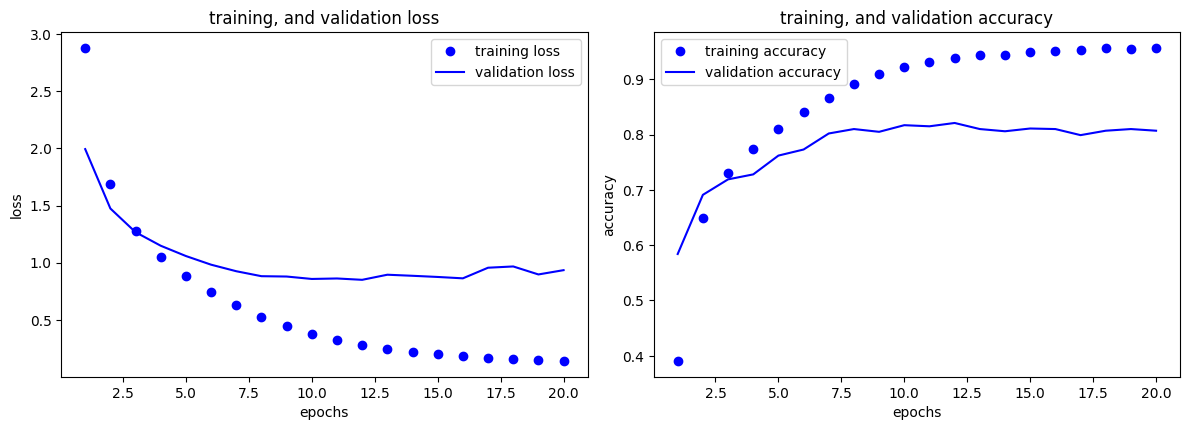

In [ ]:
import matplotlib.pyplot as plt


history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]

epochs = range(1, len(loss_values)+1)

plt.figure(figsize=(12,8))

#plotting training and validation loss
plt.subplot(2,2,1)
plt.plot(epochs, loss_values, "bo", label="training loss")
plt.plot(epochs, val_loss_values, "b", label="validation loss")
plt.title("training, and validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
#plt.show()

#plotting training and validation accuracy
plt.subplot(2,2,2)
plt.plot(epochs, accuracy, "bo", label="training accuracy")
plt.plot(epochs, val_accuracy, "b", label = "validation accuracy")
plt.title("training, and validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()



From the plots, we can observe that the validation loss starts increasing around 9 epochs, indicating overfitting. The validation accuracy also begins to plateau around this point. This suggests that training for more than 9 epochs starts to hurt the model's ability to generalize to new data.

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer = "rmsprop",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

model.fit(X_train, y_train, epochs=9, batch_size=512)
results = model.evaluate(X_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4580 - loss: 2.6451
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6907 - loss: 1.4651
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7554 - loss: 1.1167
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7999 - loss: 0.9161
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8332 - loss: 0.7528
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8645 - loss: 0.6252
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8880 - loss: 0.5207
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9103 - loss: 0.4378
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9217 - loss: 0.3634
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.8992


### Retraining the Model with Optimal Epochs and Final Evaluation

Based on the analysis of the validation plots, the model is retrained on the full training data for 9 epochs to achieve better generalization. Afterwards, the model is evaluated on the test set to determine its final performance.

In [ ]:
print(results)

[0.8991535902023315, 0.7889581322669983]


### Baseline Comparison (Random Guessing)

To put the model's accuracy into context, it's useful to compare it against a simple baseline, such as random guessing. For a 46-class classification problem, a random guess would yield an accuracy of approximately 1/46, or about 2.17%. The model's accuracy is significantly higher, indicating it has learned meaningful patterns.

In [ ]:
#how good is this when compared to a baseline
import copy
test_labels_copy =copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels) == np.array(test_labels_copy)
#float(np.sum(hits_array)) / len(test_labels)
hits_array.mean()

np.float64(0.18521816562778273)

### Generating Predictions

The `predict` method for a multiclass model with `softmax` activation returns a probability distribution (a 46-dimensional vector) for each sample, indicating the likelihood of belonging to each class. `np.argmax` can then be used to find the most probable class for each prediction.

In [ ]:
predictions = model.predict(X_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print(predictions[0].shape)
print(np.sum(predictions[0]))
print(np.argmax(predictions[0]))

(46,)
1.0
3


## Case Study 3: Regression - Boston Housing Prices

This section focuses on a regression task: predicting median housing prices in Boston suburbs during the 1970s. Unlike classification, regression predicts continuous values. The dataset is small, which introduces challenges like the need for K-fold cross-validation.

In [ ]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()
print(train_data.shape)
print(test_data.shape)


(404, 13)
(102, 13)


### Data Loading and Exploration

The Boston Housing dataset contains various features describing residential areas and their corresponding median house prices. The dataset is relatively small, with only 404 training samples and 102 test samples.

In [ ]:
train_targets[0:3]

array([15.2, 42.3, 50. ])

### Data Normalization

It's crucial to normalize numerical features for neural networks, especially when features have different scales. Here, we standardize the data by subtracting the mean and dividing by the standard deviation. This brings all features to a similar scale, which helps the neural network learn more effectively and prevents features with larger values from dominating the learning process.

In [ ]:
#normalizing the data
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

### Model Definition for Regression

For a regression task, the model architecture is slightly different:

*   Two hidden `Dense` layers with 64 units and `relu` activation.
*   An output `Dense` layer with 1 unit and *no activation function*. This is typical for scalar regression, as we want to output a raw, continuous value without constraining it to a specific range (like 0-1 for sigmoid or probabilities for softmax).

The model is compiled with:
*   `rmsprop` optimizer.
*   `mse` (Mean Squared Error) loss: The most common loss function for regression tasks. It measures the average squared difference between the predicted and actual values.
*   `mae` (Mean Absolute Error) metric: Also a common metric for regression, representing the average absolute difference between predictions and actual values. It's often more interpretable than MSE.

In [ ]:
#model definition
def build_model():
  model = keras.Sequential([
          layers.Dense(64, activation="relu"),
          layers.Dense(64, activation="relu"),
          layers.Dense(1)]
  )
  model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
  return model

### K-Fold Cross-Validation

Due to the small size of the training data, K-fold cross-validation is used. This technique helps to get a more robust evaluation of the model's performance and ensures that the model isn't overly sensitive to the particular train/validation split. Here, `k=4`, meaning the data is split into 4 folds, and the model is trained and evaluated 4 times, with a different fold serving as the validation set each time.

In [ ]:
#k-fold validation
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
  print(f"processing fold #{i}")
  val_data= train_data[i * num_val_samples: (i+1)*num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i+1) * num_val_samples]
  partial_train_data = np.concatenate(
      [train_data[:i * num_val_samples],
       train_data[i+1 * num_val_samples:]],
       axis=0
  )
  partial_train_targets = np.concatenate(
      [train_targets[:i * num_val_samples],
       train_targets[i+1 * num_val_samples:]],
      axis = 0)
  model = build_model()
  model.fit(partial_train_data, partial_train_targets,
            epochs = num_epochs, batch_size=16, verbose =0)
  val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
  all_scores.append(val_mae)



processing fold #0
processing fold #1
processing fold #2
processing fold #3


### K-Fold Validation Scores

The `all_scores` list contains the Mean Absolute Error (MAE) from each fold of the K-fold cross-validation. The mean of these scores provides an average estimate of the model's performance.

In [ ]:
all_scores

[2.021371364593506, 1.4150865077972412, 1.835674524307251, 1.696818232536316]

### Average MAE Across Folds

Calculating the mean of all MAE scores from the K-fold cross-validation provides a more reliable estimate of the model's generalization performance than a single train/validation split, especially with limited data.

In [ ]:
np.mean(all_scores)

np.float64(1.7422376573085785)

### Saving Validation Logs at Each Fold

To observe how the model's performance changes over epochs during K-fold validation, we save the `val_mae` for each epoch in each fold. This allows us to plot the average MAE history across all folds.

In [ ]:
##saving validation logs at each fold
num_epochs = 500
all_mae_histories = []
for i in range(k):
  print(f"processing fold #{i}")
  val_data= train_data[i * num_val_samples: (i+1)*num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i+1) * num_val_samples]
  partial_train_data = np.concatenate(
      [train_data[:i * num_val_samples],
       train_data[(i+1) * num_val_samples:]],
      axis = 0)
  partial_train_targets = np.concatenate(
      [train_targets[:i * num_val_samples],
       train_targets[(i+1) * num_val_samples:]],
      axis = 0)
  model = build_model()
  model.fit(partial_train_data, partial_train_targets,
            validation_data=(val_data, val_targets),
            epochs = num_epochs, batch_size=16, verbose =0)
  mae_history = model.history.history["val_mae"]
  all_mae_histories.append(mae_history)

processing fold #0
processing fold #1
processing fold #2
processing fold #3


### Calculating Average MAE History

This code calculates the average validation MAE across all K folds for each epoch. This aggregated history smooths out the noise and provides a clearer picture of the model's learning curve.

In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

### Plotting Average Validation MAE History

This plot shows the average validation MAE across all folds over the epochs. It helps identify at which epoch the model starts to overfit (where validation MAE starts to increase or plateau).

In [ ]:
#average_mae_history

The plot shows a significant drop in MAE during the initial epochs, indicating that the model is learning effectively. After approximately 80-100 epochs, the validation MAE stabilizes, and there isn't much further improvement. Beyond this point, the curve becomes noisy, suggesting that further training might lead to overfitting or diminishing returns.

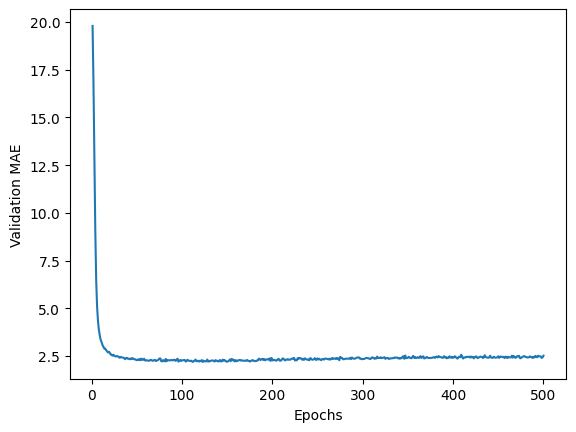

In [ ]:
plt.plot(range(1, len(average_mae_history)+1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()


### Plotting Truncated Average Validation MAE History

To get a clearer view of the MAE trend after the initial steep drop, we often plot a truncated version of the history, excluding the first few (e.g., 10) noisy epochs.

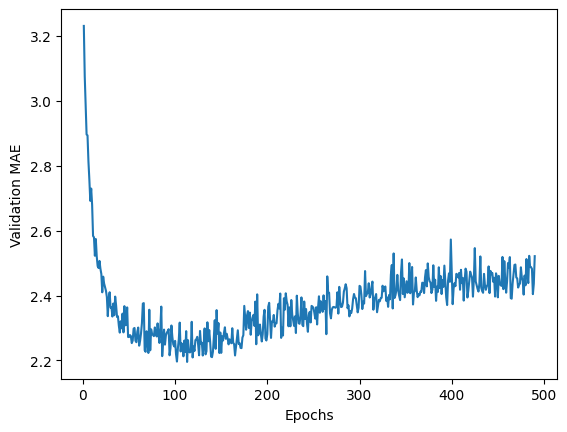

In [ ]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

The truncated plot clearly shows the stabilization of the validation MAE around the 80-epoch mark. The fluctuations afterward indicate that the model is no longer consistently improving its generalization ability.

In [ ]:
len(average_mae_history)

500

In [ ]:
len(truncated_mae_history)

490

In [ ]:
model = build_model()
model.fit(train_data, train_targets,
          epochs=80, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.0537 - mae: 2.8191 


### Final Model Training and Evaluation

Based on the MAE history, we retrain the final model on the entire training dataset (`train_data`, `train_targets`) for an optimal number of epochs (e.g., 80 epochs in this case, where the validation MAE was lowest or stabilized). This final model is then evaluated on the completely unseen test data to get the final performance metrics.

In [ ]:
test_mae_score

2.8191113471984863

### Generating Predictions

The `predict` method for the regression model outputs the predicted housing prices for the test data. These are continuous values, directly representing the model's estimation for each sample.

In [ ]:
predictions = model.predict(test_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [ ]:
predictions[0]

array([9.872375], dtype=float32)

In [ ]:
test_targets[0]

np.float64(7.2)